In [1]:
import os
import ast
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from scipy.sparse import csr_matrix
from sklearn.metrics import mean_absolute_error

In [ ]:
df_ratings = pd.read_csv("data/user_ratings_emulated.csv")

users = df_ratings['user_id'].unique()
np.random.seed(42)
test_users = set(np.random.choice(users, size=int(len(users)*0.2), replace=False))

train_data = []
test_data = []

for user_id, user_ratings in df_ratings.groupby('user_id'):
    if len(user_ratings) < 5:
        continue
    if user_id in test_users:
        hidden = user_ratings.sample(n=min(3, len(user_ratings) - 1), random_state=42)
        train = user_ratings.drop(hidden.index)
        test_data.append(hidden)
        train_data.append(train)
    else:
        train_data.append(user_ratings)

train_df = pd.concat(train_data)
test_df = pd.concat(test_data)

print(f"Обучающих оценок: {len(train_df)}")
print(f"Тестовых оценок: {len(test_df)}")
print(f"Тестовых пользователей: {len(test_users)}")

Обучающих оценок: 79377
Тестовых оценок: 1200
Тестовых пользователей: 400


In [ ]:
df_movies = pd.read_csv("data/movies_train.csv")
df_movies['genres_list'] = df_movies['genres_list'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

knn = joblib.load('models/knn_model.pkl')
feature_matrix = joblib.load('models/feature_matrix.pkl')

als = joblib.load('models/current/als_model.pkl')
user_to_idx = joblib.load('models/current/user_to_idx.pkl')
movie_to_idx = joblib.load('models/current/movie_to_idx.pkl')
movie_ids_arr = joblib.load('models/current/movie_ids.pkl')
user_ids_arr = joblib.load('models/current/user_ids.pkl')

movie_id_to_feat_idx = {mid: i for i, mid in enumerate(df_movies['id'])}

row = train_df['user_id'].map(user_to_idx).values
col = train_df['movie_id'].map(movie_to_idx).values
data = train_df['rating'].values

matrix = csr_matrix((data, (row, col)), shape=(len(user_ids_arr), len(movie_ids_arr)))

print("Модели и данные загружены")

Модели и данные загружены


c:\Users\ghgd4\Desktop\MAI\2.2\diplom\code\global_venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
_knn_cache = {}

def get_neighbors(feat_idx) -> dict:
    if feat_idx not in _knn_cache:
        d, i = knn.kneighbors(feature_matrix[feat_idx:feat_idx+1])
        _knn_cache[feat_idx] = (d[0], i[0])
    return _knn_cache[feat_idx]

def predict_als(user_id, movie_id):
    user_idx = user_to_idx.get(user_id)
    movie_idx = movie_to_idx.get(movie_id)
    if user_idx is not None and movie_idx is not None:
        user_vec = als.user_factors[user_idx]
        movie_vec = als.item_factors[movie_idx]
        pred = np.dot(user_vec, movie_vec)
        pred = 5 + pred * 5
        return np.clip(pred, 1, 10)
    return 5.0

# Предгруппируем оценки train по пользователю
user_ratings_map = {uid: g for uid, g in train_df.groupby('user_id')}

def predict_content(user_id, movie_id):
    """
    Предсказывает ОЦЕНКУ (1-10) для фильма как взвешенное среднее
    оценок пользователя по похожим фильмам (item-based KNN).
    Веса = косинусное сходство.
    """
    feat_idx = movie_id_to_feat_idx.get(movie_id)
    if feat_idx is None:
        return 5.0

    user_movies = user_ratings_map.get(user_id)
    if user_movies is None or len(user_movies) == 0:
        return 5.0

    distances, indices = get_neighbors(feat_idx)
    sim_by_feat = {idx: 1 - dist for idx, dist in zip(indices, distances)}

    num, den = 0.0, 0.0
    for mid, rating in zip(user_movies['movie_id'], user_movies['rating']):
        rated_feat_idx = movie_id_to_feat_idx.get(mid)
        if rated_feat_idx is None:
            continue
        sim = sim_by_feat.get(rated_feat_idx)
        if sim is not None and sim > 0:
            num += sim * rating
            den += sim

    if den == 0:
        return float(user_movies['rating'].mean())

    return float(np.clip(num / den, 1, 10))

als_preds = []
cont_preds = []
actuals = []
for _, row in test_df.iterrows():
    als_preds.append(predict_als(row['user_id'], row['movie_id']))
    cont_preds.append(predict_content(row['user_id'], row['movie_id']))
    actuals.append(row['rating'])

als_preds = np.array(als_preds)
cont_preds = np.array(cont_preds)
actuals = np.array(actuals)

alphas = [round(a, 2) for a in np.arange(0.0, 1.01, 0.05)]
errors = []

for alpha in alphas:
    hybrid = alpha * als_preds + (1 - alpha) * cont_preds
    mae = mean_absolute_error(actuals, hybrid)
    errors.append(mae)
    print(f"alpha={alpha:.2f}, MAE={mae:.3f}")

best_idx = int(np.argmin(errors))
best_alpha = alphas[best_idx]
print(f"\nЛучший alpha: {best_alpha} (MAE={errors[best_idx]:.3f})")

results_df = pd.DataFrame({'alpha': alphas, 'mae': errors})

alpha=0.00, MAE=1.142
alpha=0.05, MAE=1.130
alpha=0.10, MAE=1.119
alpha=0.15, MAE=1.108
alpha=0.20, MAE=1.098
alpha=0.25, MAE=1.089
alpha=0.30, MAE=1.081
alpha=0.35, MAE=1.074
alpha=0.40, MAE=1.067
alpha=0.45, MAE=1.062
alpha=0.50, MAE=1.057
alpha=0.55, MAE=1.053
alpha=0.60, MAE=1.050
alpha=0.65, MAE=1.048
alpha=0.70, MAE=1.046
alpha=0.75, MAE=1.045
alpha=0.80, MAE=1.045
alpha=0.85, MAE=1.045
alpha=0.90, MAE=1.047
alpha=0.95, MAE=1.049
alpha=1.00, MAE=1.052

Лучший alpha: 0.8 (MAE=1.045)


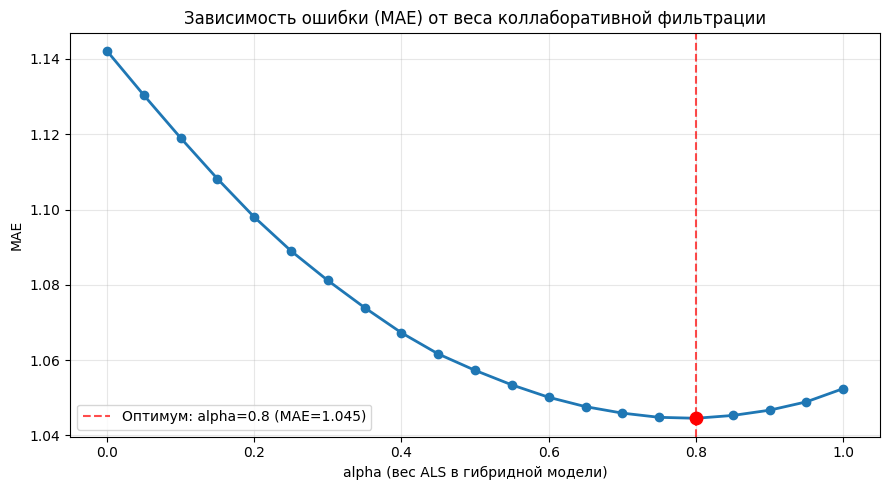

In [7]:
# График зависимости MAE от alpha
os.makedirs('pictures', exist_ok=True)

plt.figure(figsize=(9, 5))
plt.plot(results_df['alpha'], results_df['mae'], marker='o', linewidth=2)
plt.axvline(best_alpha, color='red', linestyle='--', alpha=0.7,
            label=f'Оптимум: alpha={best_alpha} (MAE={errors[best_idx]:.3f})')
plt.scatter([best_alpha], [errors[best_idx]], color='red', zorder=5, s=80)
plt.xlabel('alpha (вес ALS в гибридной модели)')
plt.ylabel('MAE')
plt.title('Зависимость ошибки (MAE) от веса коллаборативной фильтрации')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('pictures/mae_vs_alpha.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
joblib.dump(best_alpha, 'models/best_alpha.pkl')
print("Лучшее значение alpha сохранено")

Лучшее значение alpha сохранено
